# Module 10: Machine Learning with Scikit-Learn
# Lab 05: Model Evaluation, Hyperparameter Tuning & Pipelines

**Prepared by Information Tech Consultants Ltd**

---

## 🎯 Learning Objectives
By the end of this notebook, you will be able to:
- [ ] Perform cross-validation to reliably evaluate models
- [ ] Tune hyperparameters using GridSearchCV and RandomizedSearchCV
- [ ] Build end-to-end ML pipelines using sklearn.pipeline
- [ ] Create a reproducible, production-ready ML workflow

**⏱ Estimated Time:** 75 minutes  
**📋 Prerequisites:** Module 10 Labs 01–04

In [1]:
# ============================================================
# 📦 Environment Setup — Run this cell first!
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

data = load_breast_cancer(as_frame=True)
X = data.frame.drop("target", axis=1)
y = data.frame["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data ready! Train: {len(X_train)} | Test: {len(X_test)}")

✅ Data ready! Train: 455 | Test: 114


In [2]:
# ============================================================
# 🛠 Helper Functions (run once, use throughout)
# ============================================================

from IPython.display import HTML, display

def info_box(title, content, color="#0092D6", bg="#E3F2FD"):
    """Display a styled information callout box."""
    display(HTML(f"""
    <div style="background:{bg};padding:15px;border-left:5px solid {color};
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>💡 {title}</strong><br>{content}</div>"""))

def warning_box(title, content):
    """Display a warning callout box."""
    display(HTML(f"""
    <div style="background:#FFF3E0;padding:15px;border-left:5px solid #FF9800;
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>⚠️ {title}</strong><br>{content}</div>"""))

def interview_box(question, key_points):
    """Display an interview question callout box."""
    display(HTML(f"""
    <div style="background:#F3E5F5;padding:15px;border-left:5px solid #9C27B0;
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>🎯 Interview Question</strong><br><em>"{question}"</em><br><br>
    <strong>Key Points:</strong> {key_points}</div>"""))

def success_box(content):
    """Display a success/best practice box."""
    display(HTML(f"""
    <div style="background:#E8F5E9;padding:15px;border-left:5px solid #4CAF50;
    margin:10px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>✅ Best Practice</strong><br>{content}</div>"""))

def exercise_header(num, title, difficulty="⭐"):
    """Display a formatted exercise header."""
    display(HTML(f"""
    <div style="background:#E8EAF6;padding:15px;border-left:5px solid #0092D6;
    margin:15px 0;border-radius:4px;font-family:Calibri,Arial,sans-serif;">
    <strong>🏋️ Exercise {num}: {title}</strong> | Difficulty: {difficulty}</div>"""))

def draw_pipeline(steps, arrow="→"):
    """Draw a simple pipeline flow diagram."""
    flow = f" {arrow} ".join([f"[{s}]" for s in steps])
    display(HTML(f"""
    <div style="background:#F5F5F5;padding:20px;border-radius:8px;
    text-align:center;font-family:monospace;font-size:16px;margin:10px 0;">
    {flow}</div>"""))

print("✅ Helper functions loaded!")

✅ Helper functions loaded!


## 🚀 Complete Working Example

Let's build a complete pipeline that preprocesses data, tunes a Random Forest, and evaluates it — all in one clean workflow.

In [3]:
# ============================================================
# 🚀 COMPLETE WORKING EXAMPLE — Run me first!
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

# Step 1: Build a pipeline (preprocessing + model in one object)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])

# Step 2: Cross-validate to get a reliable accuracy estimate
cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
print(f"Cross-Validation F1 Scores: {cv_scores.round(4)}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Step 3: Tune hyperparameters
param_grid = {
    "rf__n_estimators": [50, 100],
    "rf__max_depth": [3, 5, 10],
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

# Step 4: Evaluate on test set
y_pred = grid_search.predict(X_test)
print(f"\nTest Set F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\n🎉 Complete pipeline with tuning done!")

Cross-Validation F1 Scores: [0.9831 0.9573 0.9821 0.9649 0.9483]
Mean F1: 0.9671 (+/- 0.0137)

Best Parameters: {'rf__max_depth': 5, 'rf__n_estimators': 100}
Best CV F1 Score: 0.9689

Test Set F1 Score: 0.9722

🎉 Complete pipeline with tuning done!


---
## 📖 Section 1: Cross-Validation

**What:** Cross-validation splits the training data into multiple folds, trains and evaluates the model on each fold, and averages the results. This gives a much more reliable performance estimate than a single train/test split.

**Why it matters:** A single test score can be misleading — you might just get lucky (or unlucky) with one particular split. Cross-validation shows you how consistent your model is.

**Analogy:** Instead of taking one exam, imagine taking the same exam 5 times with different questions each time. Your average score is a much better measure of your knowledge than any single attempt.

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Scale data first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-fold cross-validation
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring="accuracy")

print("5-Fold Cross-Validation Results:")
print("=" * 40)
for i, score in enumerate(cv_scores):
    bar = "█" * int(score * 40)
    print(f"  Fold {i+1}: {score:.4f}  {bar}")
print(f"\n  Mean:   {cv_scores.mean():.4f}")
print(f"  Std:    {cv_scores.std():.4f}")

info_box(
    "Why Cross-Validation Matters",
    "A single train/test split can give misleading results. Cross-validation "
    "uses <b>all the data for both training and testing</b> (just not at the same time). "
    "The standard deviation tells you how <b>stable</b> the model is across different data splits."
)

5-Fold Cross-Validation Results:
  Fold 1: 0.9780  ███████████████████████████████████████
  Fold 2: 0.9451  █████████████████████████████████████
  Fold 3: 0.9780  ███████████████████████████████████████
  Fold 4: 0.9560  ██████████████████████████████████████
  Fold 5: 0.9341  █████████████████████████████████████

  Mean:   0.9582
  Std:    0.0176


Model                   Mean F1        Std
Logistic Reg             0.9792     0.0141
KNN (k=5)                0.9694     0.0163
SVM                      0.9810     0.0099
Random Forest            0.9671     0.0137


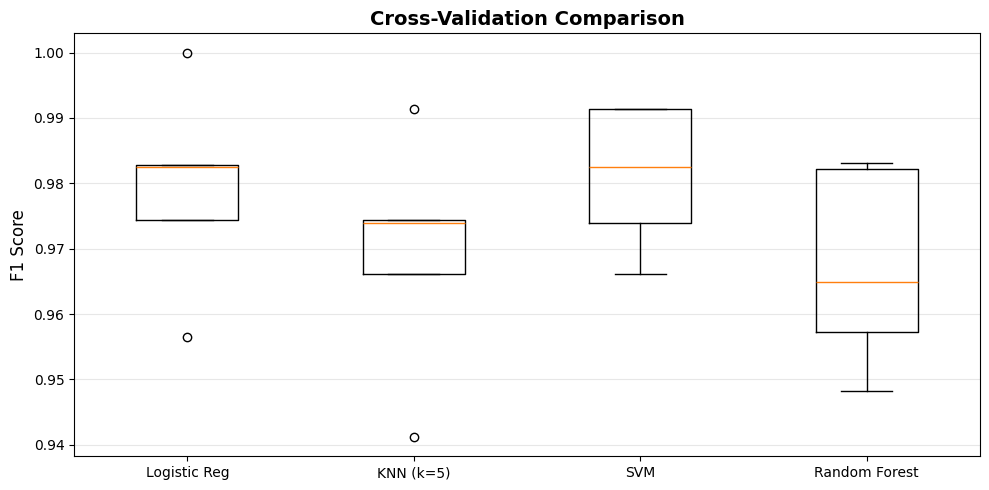

In [5]:
# Compare multiple models using cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Reg": LogisticRegression(max_iter=5000, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

print(f"{'Model':<20} {'Mean F1':>10} {'Std':>10}")
print("=" * 42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="f1")
    cv_results[name] = scores
    print(f"{name:<20} {scores.mean():10.4f} {scores.std():10.4f}")

# Visualise with a box plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Cross-Validation Comparison", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 📖 Section 2: Hyperparameter Tuning

**What:** Hyperparameters are settings you choose *before* training (like max_depth, n_estimators, k). Tuning means finding the best combination of these settings.

**Analogy:** When baking a cake, hyperparameters are like oven temperature and baking time. You can't change them during baking — you need to experiment with different settings to find the perfect combination.

In [7]:
# GridSearchCV: tries ALL combinations (exhaustive but slow)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
}

# Total combinations = 3 × 4 × 3 = 36
total = 1
for v in param_grid.values():
    total *= len(v)
print(f"Total combinations to try: {total}")
print(f"With 5-fold CV: {total * 5} model fits!\n")

grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,        # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1 Score: {grid_search.best_score_:.4f}")

# Evaluate on test set
X_test_scaled = scaler.transform(X_test)
y_pred = grid_search.predict(X_test_scaled)
print(f"Test F1 Score:    {f1_score(y_test, y_pred):.4f}")

Total combinations to try: 36
With 5-fold CV: 180 model fits!

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
  max_depth: 10
  min_samples_split: 2
  n_estimators: 200

Best CV F1 Score: 0.9706
Test F1 Score:    0.9722


In [9]:
# RandomizedSearchCV: tries RANDOM combinations (faster, often just as good)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

rf = RandomForestClassifier(random_state=42)

# Define parameter distributions (not a fixed grid)
param_distributions = {
    "n_estimators": randint(50, 300),        # Random integer between 50-300
    "max_depth": [3, 5, 10, 15, None],       # Choices
    "min_samples_split": randint(2, 20),     # Random integer between 2-20
    "min_samples_leaf": randint(1, 10),      # Random integer between 1-10
}

random_search = RandomizedSearchCV(
    rf, param_distributions,
    n_iter=50,            # Only try 50 random combinations (vs 36 x more for grid)
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters (Randomized Search):")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1 Score: {random_search.best_score_:.4f}")

y_pred_rand = random_search.predict(X_test_scaled)
print(f"Test F1 Score:    {f1_score(y_test, y_pred_rand):.4f}")

interview_box(
    "When would you use GridSearchCV vs RandomizedSearchCV?",
    "<b>GridSearchCV:</b> Small parameter spaces (< 100 combinations). Guarantees finding the best.<br>"
    "<b>RandomizedSearchCV:</b> Large parameter spaces. Faster — often finds near-optimal results with "
    "far fewer iterations. Research shows random search is usually more efficient."
)

Best Parameters (Randomized Search):
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 196

Best CV F1 Score: 0.9706
Test F1 Score:    0.9722


---
## 📖 Section 3: Scikit-Learn Pipelines

**What:** A Pipeline chains multiple steps (preprocessing + model) into a single object that you can fit, predict, and tune as one unit.

**Why it matters:** Pipelines prevent data leakage, make your code cleaner, and ensure reproducibility. They're essential for production ML.

**Analogy:** Think of a factory assembly line. Raw materials go in one end, and finished products come out the other. Each step in the pipeline transforms the data before passing it to the next step.

In [10]:
# Without a pipeline (messy, error-prone)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# model = RandomForestClassifier()
# model.fit(X_train_scaled, y_train)
# y_pred = model.predict(X_test_scaled)

# With a pipeline (clean, safe)
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),                     # Step 1: Scale features
    ("classifier", RandomForestClassifier(random_state=42))  # Step 2: Classify
])

# One line to train everything
pipe.fit(X_train, y_train)

# One line to predict (scaling happens automatically!)
y_pred = pipe.predict(X_test)

print(f"Pipeline F1 Score: {f1_score(y_test, y_pred):.4f}")

draw_pipeline(["Raw Data", "StandardScaler", "RandomForest", "Predictions"])

success_box(
    "Pipelines handle <code>fit_transform</code> and <code>transform</code> automatically. "
    "You never have to worry about accidentally fitting the scaler on test data!"
)

Pipeline F1 Score: 0.9722


In [12]:
# Pipeline + GridSearchCV = the dream team
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer

# A more complete pipeline with imputation, scaling, and classification
full_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=42)),
])

# Note: use double underscore to reference pipeline step params
param_grid = {
    "imputer__strategy": ["mean", "median"],
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [3, 5, 10],
}

grid = GridSearchCV(full_pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Pipeline Configuration:")
for param, value in grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1: {grid.best_score_:.4f}")
print(f"Test F1:    {f1_score(y_test, grid.predict(X_test)):.4f}")

info_box(
    "Pipeline Parameter Names",
    "To access parameters inside a pipeline, use the format:<br>"
    "<code>step_name__parameter_name</code><br>"
    "For example: <code>classifier__n_estimators</code> sets n_estimators "
    "for the step named 'classifier'."
)

Best Pipeline Configuration:
  classifier__max_depth: 10
  classifier__n_estimators: 200
  imputer__strategy: mean

Best CV F1: 0.9706
Test F1:    0.9722


In [15]:
# Saving and loading a trained pipeline
import os
import pickle

# Ensure path exists
os.makedirs("Module_10_Machine_Learning", exist_ok=True)
model_path = "Module_10_Machine_Learning/best_model.pkl"

# Save the best model
best_pipeline = grid.best_estimator_
with open(model_path, "wb") as f:
    pickle.dump(best_pipeline, f)

# Load it back
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

# Verify it works
y_pred_loaded = loaded_model.predict(X_test)
print(f"Loaded model F1: {f1_score(y_test, y_pred_loaded):.4f}")
print("\n✅ Model saved and loaded successfully!")

info_box(
    "Model Persistence",
    "Use <code>pickle</code> or <code>joblib</code> to save trained models. "
    "The saved pipeline includes ALL preprocessing steps, so you can make predictions "
    "on raw data without any additional code."
)

interview_box(
    "How would you deploy a machine learning model?",
    "1. Train and validate with cross-validation<br>"
    "2. Save the full pipeline (preprocessing + model) with pickle/joblib<br>"
    "3. Wrap in a Flask/FastAPI endpoint<br>"
    "4. Add input validation and error handling<br>"
    "5. Monitor predictions and retrain periodically<br>"
    "<em>Key: Save the PIPELINE, not just the model — otherwise you'll need "
    "to recreate preprocessing steps manually.</em>"
)

Loaded model F1: 0.9722

✅ Model saved and loaded successfully!


---
## 🏋️ Exercises

In [35]:
exercise_header(1, "Cross-Validate Different Models", "⭐")

# Run this and answer the questions
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Reg": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree (d=3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Decision Tree (d=20)": DecisionTreeClassifier(max_depth=20, random_state=42),
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="f1")
    print(name, scores)
    print(f"{name:<25}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")


# ❓ Questions:
# 1. Which model has the highest mean F1 score?
# Logistic Regression has the highest mean F1 score.
# 2. Which model has the most consistent scores (lowest std)?
# Decision Tree with max_depth=3 has the lowest std, indicating more consistent performance across folds.
# 3. The deep tree (d=20) has lower CV scores than d=3 — why?
# The deep tree (d=20) is likely overfitting the training data, resulting in poorer generalization to unseen data, hence lower cross-validation scores.

Logistic Reg [0.98245614 0.97435897 1.         0.98275862 0.95652174]
Logistic Reg               Mean: 0.9792  Std: 0.0141
Decision Tree (d=3) [0.95652174 0.92307692 0.95412844 0.94545455 0.94915254]
Decision Tree (d=3)        Mean: 0.9457  Std: 0.0119
Decision Tree (d=20) [0.9380531  0.91525424 0.94444444 0.91891892 0.94915254]
Decision Tree (d=20)       Mean: 0.9332  Std: 0.0136


In [38]:
exercise_header(2, "Tune KNN with RandomizedSearchCV", "⭐⭐")

# TODO: Use RandomizedSearchCV to find the best k and distance metric for KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

knn = KNeighborsClassifier()

param_dist = {
    "n_neighbors": list(range(1, 31)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

# YOUR CODE HERE:
# 1. Create RandomizedSearchCV with n_iter=30, cv=5, scoring="f1"
random_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=30,
    cv = 5,
    scoring="f1",
)
# 2. Fit on X_train_scaled, y_train
random_search.fit(X_train_scaled, y_train)
# 3. Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)
# 4. Evaluate on test set
y_pred = random_search.predict(X_test_scaled)
print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}") 

Best Parameters: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}
Best Score: 0.9729301754268995
Test F1 Score: 0.9718


In [49]:
exercise_header(3, "Build a Full Pipeline from Scratch", "⭐⭐⭐")

# Challenge: Build a pipeline for the wine dataset that includes:
# 1. SimpleImputer (median)
# 2. StandardScaler
# 3. A classifier of your choice
# Then tune it with GridSearchCV and report the best score.

from sklearn.datasets import load_wine
from sklearn.pipeline import Pipeline

wine = load_wine(as_frame=True)
X_wine = wine.frame.drop("target", axis=1)
y_wine = wine.frame["target"]

# YOUR CODE HERE:
# 1. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)
# 2. Create a Pipeline  
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=42)),
])
# 3. Define a param_grid
param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [3, 5, None],
}
# 4. Run GridSearchCV

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",  # Use macro F1 for multi-class
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
# 5. Print best params and test set accuracy
print(grid.best_params_.items())
for param, value in grid.best_params_.items():
    print(f"{param}: {value}")
print("Best CV F1 macro Score:", grid.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
dict_items([('classifier__max_depth', 5), ('classifier__n_estimators', 100)])
classifier__max_depth: 5
classifier__n_estimators: 100
Best CV F1 macro Score: 0.9788068209740036


---
## 📋 Solutions

<details>
<summary>Click to expand Exercise 2 solution</summary>

```python
random_search = RandomizedSearchCV(
    knn, param_dist, n_iter=30, cv=5, scoring="f1", random_state=42
)
random_search.fit(X_train_scaled, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best CV F1: {random_search.best_score_:.4f}")

y_pred = random_search.predict(X_test_scaled)
print(f"Test F1: {f1_score(y_test, y_pred):.4f}")
```

</details>

<details>
<summary>Click to expand Exercise 3 solution</summary>

```python
X_tr, X_te, y_tr, y_te = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=42)),
])

param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [3, 5, 10, None],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_tr, y_tr)

print(f"Best params: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")
print(f"Test accuracy: {grid.score(X_te, y_te):.4f}")
```

</details>

---
## 🎯 Key Takeaways

1. **Cross-validation** gives reliable performance estimates — never rely on a single train/test split
2. **GridSearchCV** tries all combinations — use for small search spaces
3. **RandomizedSearchCV** samples random combinations — faster and often just as good
4. **Pipelines** chain preprocessing and modelling into a single, safe, reproducible object
5. **Always save the full pipeline** (not just the model) for deployment

## ✅ Self-Assessment Checklist
- [ ] I can perform cross-validation and interpret the results
- [ ] I can tune hyperparameters with GridSearchCV and RandomizedSearchCV
- [ ] I can build a complete ML pipeline with sklearn.pipeline
- [ ] I understand how to save and load a trained pipeline

## 📚 Next Steps
- **Next Module:** Module 11 — Advanced Topics & Real-World Projects
- **Capstone Idea:** Build a full pipeline on a real dataset from Kaggle
- **Review:** Revisit Labs 01–04 and try the exercises without looking at solutions

---

## 🎯 Module 10 Summary — What You've Learned

| Lab | Topics Covered |
|-----|---------------|
| Lab 01 | ML Workflow, Train/Test Split, Scaling, Imputation, Encoding, Feature Selection |
| Lab 02 | Linear Regression, Ridge, Lasso, ElasticNet, Regression Metrics |
| Lab 03 | Logistic Regression, KNN, Decision Trees, Random Forest, Classification Metrics, ROC-AUC |
| Lab 04 | K-Means, DBSCAN, Hierarchical Clustering, PCA |
| Lab 05 | Cross-Validation, GridSearchCV, RandomizedSearchCV, Pipelines |

You now have the tools to tackle real-world ML problems from start to finish!

---
*Prepared by Information Tech Consultants Ltd*